## Extracting Tensorboard Data

In [1]:
import matplotlib.pyplot as plt
import numpy as np


def plot_metric(
    df,
    metric,
    dataset,
    version="v1",
    ax1=None,
    fontsize=16
):

    # Filtrar dataset y versión
    data = df[
        (df["dataset"] == dataset) &
        (df["version"] == version)
    ].copy()

    if data.empty:
        raise ValueError(
            f"No hay datos para dataset={dataset}, version={version}"
        )

    # Columnas de la métrica
    test_col = f"test_metrics/{metric}"
    val_col = f"val_metrics/{metric}"

    # Ordenar por test
    data = data.sort_values(
        test_col,
        ascending=False
    )

    # Crear eje si no se entrega
    if ax1 is None:
        fig, ax1 = plt.subplots(
            figsize=(10, 6)
        )

    x = np.arange(len(data))
    width = 0.35


    # =========================
    # Barras performance
    # =========================

    ax1.bar(
        x - width/2,
        data[val_col],
        width,
        label="Validation",
        alpha=0.85
    )

    ax1.bar(
        x + width/2,
        data[test_col],
        width,
        label="Test",
        alpha=0.85
    )


    # =========================
    # Eje izquierdo
    # =========================

    ax1.set_ylim(0, 1.05)

    ax1.set_yticks(
        np.arange(0, 1.1, 0.1)
    )

    ax1.set_ylabel(
        metric.replace("_", " ").upper(),
        fontsize=fontsize
    )

    ax1.tick_params(
        axis="y",
        labelsize=fontsize-2
    )

    ax1.set_xticks(x)

    ax1.set_xticklabels(
        data["model"],
        rotation=45,
        ha="right",
        fontsize=fontsize-2
    )

    ax1.grid(
        axis="y",
        linestyle="--",
        alpha=0.5
    )


    # =========================
    # Segundo eje recursos
    # =========================

    ax2 = ax1.twinx()

    ax2.plot(
        x,
        data["Tiempo_normalized"],
        marker="o",
        linewidth=3,
        linestyle="--",
        color="green",
        label="Training time"
    )

    ax2.plot(
        x,
        data["VRAM_normalized"],
        marker="s",
        linewidth=3,
        linestyle="-.",
        color="red",
        label="VRAM"
    )

    ax2.set_ylim(0, 1.05)

    ax2.set_yticks(
        np.arange(0, 1.1, 0.1)
    )

    ax2.set_ylabel(
        "Normalized resources",
        fontsize=fontsize
    )

    ax2.tick_params(
        axis="y",
        labelsize=fontsize-2
    )


    # =========================
    # Leyenda combinada
    # =========================

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        handles1 + handles2,
        labels1 + labels2,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.18),
        ncol=4,
        fontsize=fontsize-2
    )


    # =========================
    # Título
    # =========================

    ax1.set_title(
        f"{dataset.capitalize()} - {version} - {metric.upper()}",
        fontsize=fontsize+2
    )

    return ax1

def calculate_agg(df, column, is_time=False, title="", figsize=(5,5)):

    data = (
        df.groupby("version")[column]
        .agg(["min", "mean", "max"])
    )

    if is_time:
        data = data.div(60)

    ax = data.plot(
        kind="bar",
        figsize=figsize,
        width=0.8
    )

    plt.ylabel(title)
    plt.xlabel("Version")
    plt.xticks(rotation=0)

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.5
    )

    plt.legend(
        ["Minimum", "Average", "Maximum"],
        title=""
    )

    plt.tight_layout()
    plt.show()

In [2]:
import glob
from pathlib import Path
from tensorboard.backend.event_processing import event_accumulator
import numpy as np
import pandas as pd
def extract_tensorboard_data(log_glob, namespace="timing/total_training_seconds", name="valor",agg=max):
    all_data = []
    for path in glob.glob(log_glob):

        ea = event_accumulator.EventAccumulator(path)
        ea.Reload()
        events = ea.Scalars(namespace)
        path = Path(path)
        log_dict = dict(dataset=path.parent.name.split("_")[0], model=path.parent.name.split("_")[1], version=path.name, value = agg([e.value for e in events]))
        all_data.append(log_dict)

    df = pd.DataFrame(all_data).rename(columns={'value': name})
    df["dataset"]=df["dataset"].str.lower()
    return df

df_time = extract_tensorboard_data("tb_logs/*/*", namespace = "timing/total_training_seconds", name="Tiempo [s]")
df_cpu = extract_tensorboard_data("tb_logs/*/*", namespace = "system/cpu_percent", name="CPU [%]", agg=np.mean)
df_ram = extract_tensorboard_data("tb_logs/*/*", namespace = "system/gpu_memory_allocated_gb", name="VRAM [GB]", agg=max)

df = df_time.merge(df_cpu, on=['dataset', 'model', 'version']).merge(df_ram, on=['dataset', 'model', 'version'])

## Vaihingen

In [3]:
df_vaihingen = pd.read_csv("Vaihingen.csv")
full_df_vaihingen = df_vaihingen.merge(df, on=['dataset', 'model', 'version'], how = "left")
full_df_vaihingen["Tiempo_normalized"] = full_df_vaihingen["Tiempo [s]"]/full_df_vaihingen["Tiempo [s]"].max()
full_df_vaihingen["VRAM_normalized"] = full_df_vaihingen["VRAM [GB]"]/full_df_vaihingen["VRAM [GB]"].max()
full_df_vaihingen

,model,dataset,version,losses/val_loss,val_metrics/accuracy,val_metrics/f1,val_metrics/miou,val_metrics/precision,val_metrics/recall,losses/test_loss,test_metrics/accuracy,test_metrics/f1,test_metrics/miou,test_metrics/precision,test_metrics/recall,Tiempo [s],CPU [%],VRAM [GB],Tiempo_normalized,VRAM_normalized
0,unetpp,vaihingen,v1,0.176371,0.707272,0.712078,0.680422,0.717720,0.707272,0.218291,0.706363,0.706181,0.677134,0.819631,0.706363,2146.436768,11.405333,15.374883,0.986068,1.000000
1,unetpp,vaihingen,v2,0.514629,0.705649,0.707801,0.651339,0.711008,0.705649,0.671436,0.701422,0.697511,0.664612,0.696797,0.701422,2176.762939,10.410000,15.374882,1.000000,1.000000
2,unet,vaihingen,v1,0.229464,0.719446,0.704430,0.668408,0.693219,0.719446,0.250903,0.731081,0.699890,0.667238,0.673878,0.731081,1735.094360,11.146000,13.162746,0.797098,0.856120
3,unet,vaihingen,v2,0.486850,0.712652,0.708613,0.678732,0.705037,0.712652,0.668103,0.709105,0.701311,0.669469,0.695967,0.709105,1986.856812,10.596000,13.160320,0.912758,0.855962
4,segnet,vaihingen,v1,0.278919,0.611700,0.621350,0.513146,0.644127,0.611700,0.327308,0.592642,0.600356,0.488127,0.642245,0.592642,1917.877441,9.478000,6.323553,0.881069,0.411291
5,segnet,vaihingen,v2,0.585835,0.542334,0.536081,0.476843,0.530969,0.542334,0.698652,0.531711,0.519588,0.436658,0.513022,0.531711,1844.287354,9.094000,6.323553,0.847261,0.411291
6,segformer,vaihingen,v1,0.199863,0.693965,0.695735,0.654252,0.701198,0.693965,0.243076,0.677905,0.681656,0.640229,0.695262,0.677905,1419.229492,13.075728,9.017122,0.651991,0.586484
7,segformer,vaihingen,v2,0.483260,0.673950,0.680922,0.622897,0.693628,0.673950,0.667339,0.688113,0.672213,0.574802,0.675049,0.688113,1419.848267,12.444000,8.991059,0.652275,0.584789
8,upernet,vaihingen,v1,0.325766,0.568225,0.588646,0.507694,0.635385,0.568225,0.356215,0.590209,0.580022,0.458354,0.608380,0.590209,1193.751221,13.780000,6.920928,0.548407,0.450145
9,upernet,vaihingen,v2,0.639549,0.498027,0.494722,0.425739,0.603110,0.498027,0.761838,0.489346,0.474116,0.372519,0.620584,0.489346,1197.373901,13.700000,6.920928,0.550071,0.450145


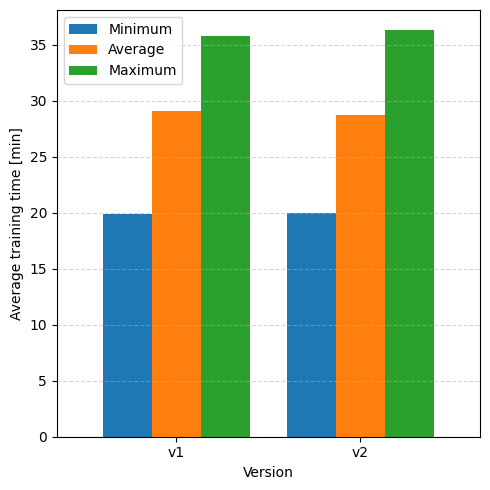

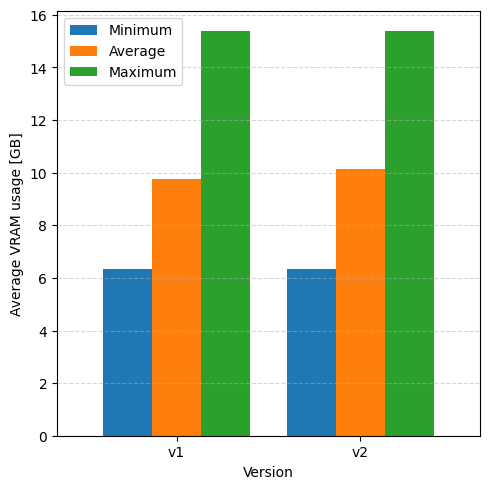

In [4]:
calculate_agg(full_df_vaihingen, column="Tiempo [s]", is_time=True, title="Average training time [min]")
calculate_agg(full_df_vaihingen, column="VRAM [GB]", title="Average VRAM usage [GB]")

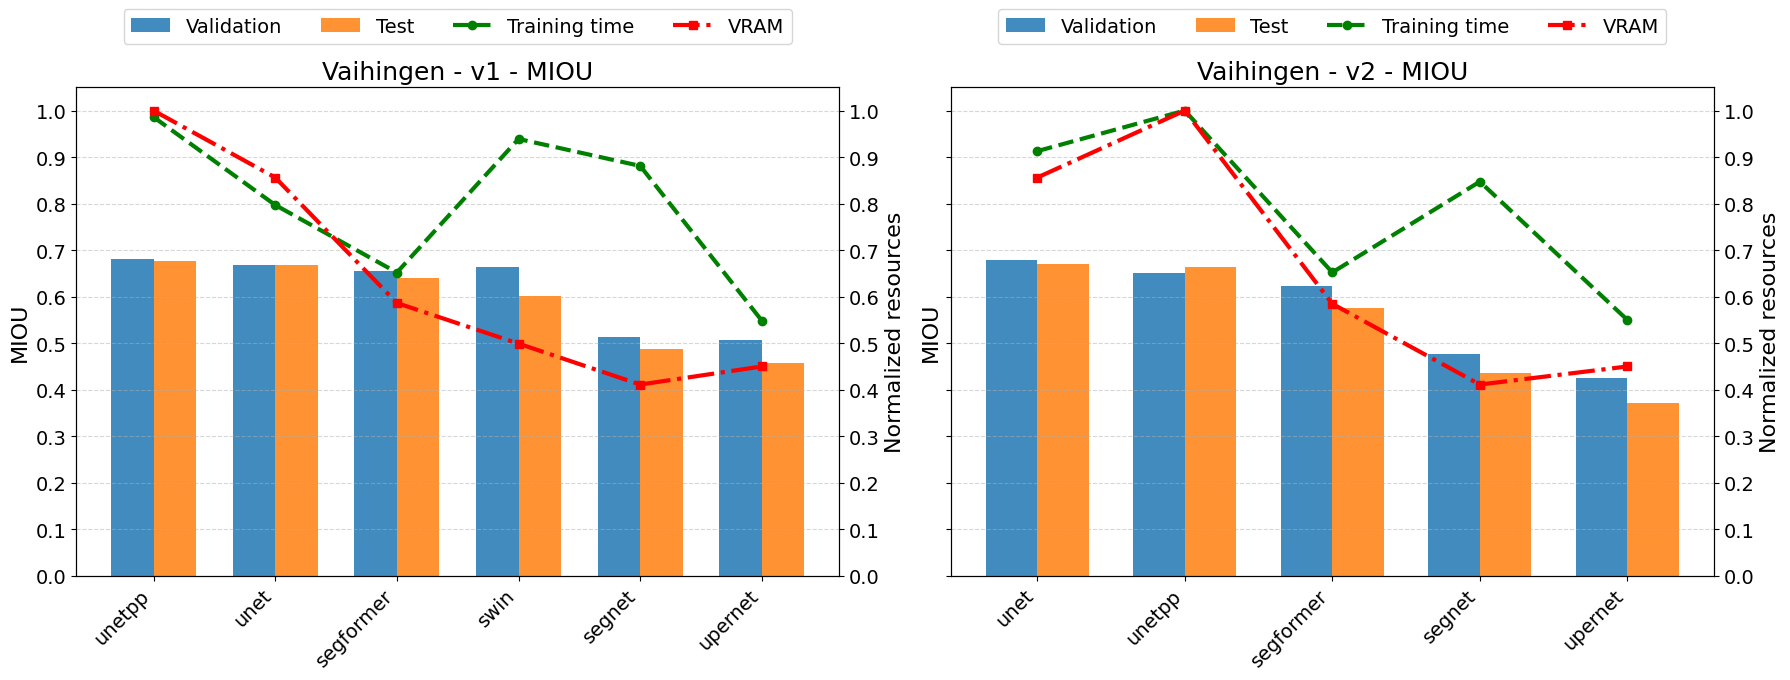

In [5]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 7),
    sharey=True
)

plot_metric(
    full_df_vaihingen,
    metric="miou",
    dataset="vaihingen",
    version="v1",
    ax1=axes[0],
    fontsize=16
)

plot_metric(
    full_df_vaihingen,
    metric="miou",
    dataset="vaihingen",
    version="v2",
    ax1=axes[1],
    fontsize=16
)

plt.tight_layout()
plt.show()


## Conclusiones

* Modelos tienden a entregar un mIOU mayor a 0.6 para los 4 modelos más potentes (Unets, Swin y Segformer).
* En general los resultados de la v1 (usando DiceLoss) tienden a entregar mejores resultados en términos de mIOU.
    * Se puede ver que el uso de CrossEntropy tiene un efecto negativo en Upernet, degradando su rendimiento considerablemente, incluso por debajo de la Segnet (Baseline).
    * Segformer también se ve afectado bajando del umbral del 0.6.

* Si bien se puede ver que la generalización es adecuada, los modelos basados más complejos tienden a tener un mayor grado de overfitting. Notándose más en Upernet (CNN), Swin y Segformer (Transformers).

* La diferencia de performance entre Unets y Segformer es casi imperceptible para v1. En Swin tiende a haber un poquito más de diferencia.
    * Segnet y Upernet tienden a tener la diferencia más significativa.
    * En general Unetpp es el modelo más caro computacionalmente y no tiene gran ventaja sobre los otros modelos.
    * Los tiempos de Unetpp, Segnet y Swin tienden a ser más largos que el resto de los modelos. Pero el uso de VRAM es significativamente menor en Swin y la performance de Segnet es significativamente menor que el resto. 
* De la misma manera el modelo con mayor performance y menos utilización de recursos es Segformer para ambas configuraciones.

## Potsdam

In [6]:
df_potsdam = pd.read_csv("Potsdam.csv")
full_df_potsdam = df_potsdam.merge(df, on=['dataset', 'model', 'version'], how = "left")
full_df_potsdam["Tiempo_normalized"] = full_df_potsdam["Tiempo [s]"]/full_df_potsdam["Tiempo [s]"].max()
full_df_potsdam["VRAM_normalized"] = full_df_potsdam["VRAM [GB]"]/full_df_potsdam["VRAM [GB]"].max()
full_df_potsdam

,model,dataset,version,losses/val_loss,val_metrics/accuracy,val_metrics/f1,val_metrics/miou,val_metrics/precision,val_metrics/recall,losses/test_loss,test_metrics/accuracy,test_metrics/f1,test_metrics/miou,test_metrics/precision,test_metrics/recall,Tiempo [s],CPU [%],VRAM [GB],Tiempo_normalized,VRAM_normalized
0,unetpp,potsdam,v1,0.209509,0.841206,0.854553,0.738679,0.873738,0.841206,0.209464,0.806241,0.815745,0.718369,0.833817,0.806241,13674.534180,10.601333,15.278217,1.000000,1.000000
1,unetpp,potsdam,v2,0.504371,0.850682,0.855641,0.740506,0.862102,0.850682,0.491016,0.815576,0.813196,0.715789,0.811179,0.815576,13671.311523,10.888000,15.278217,0.999764,1.000000
2,unet,potsdam,v1,0.214934,0.841486,0.854632,0.737064,0.872717,0.841486,0.220416,0.799785,0.810573,0.712353,0.829294,0.799785,11142.870117,11.744667,13.125343,0.814863,0.859089
3,unet,potsdam,v2,0.483561,0.853745,0.858482,0.742158,0.864245,0.853745,0.464461,0.821267,0.819844,0.721090,0.818611,0.821267,11151.666016,11.890000,13.125343,0.815506,0.859089
4,segnet,potsdam,v1,0.280804,0.782074,0.793160,0.655404,0.812072,0.782074,0.277462,0.754736,0.762459,0.648901,0.776915,0.754736,11129.396484,8.605941,11.620020,0.813878,0.760561
5,segnet,potsdam,v2,0.483647,0.809622,0.808334,0.666302,0.809160,0.809622,0.452665,0.771308,0.761678,0.646759,0.759439,0.771308,11204.351562,8.740000,6.445073,0.819359,0.421847
6,segformer,potsdam,v1,0.209836,0.847171,0.856883,0.740157,0.869412,0.847171,0.215469,0.806455,0.816075,0.718460,0.830098,0.806455,8229.362305,14.219333,9.004192,0.601802,0.589348
7,segformer,potsdam,v2,0.569583,0.838801,0.847661,0.733425,0.860706,0.838801,0.523058,0.805228,0.807597,0.708971,0.811185,0.805228,8072.409180,14.462000,9.004192,0.590324,0.589348
8,upernet,potsdam,v1,0.245177,0.810272,0.823594,0.695730,0.844014,0.810272,0.244997,0.775697,0.787714,0.681150,0.808213,0.775697,7746.701660,14.352000,6.897563,0.566506,0.451464
9,upernet,potsdam,v2,0.580329,0.828717,0.824054,0.692907,0.821095,0.828717,0.532294,0.802929,0.790602,0.685023,0.784168,0.802929,7790.504395,14.328000,6.897563,0.569709,0.451464


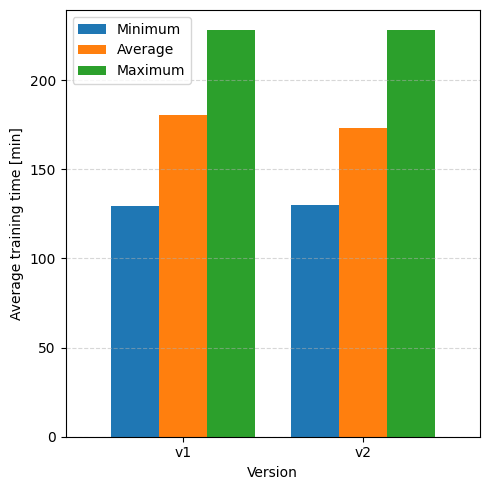

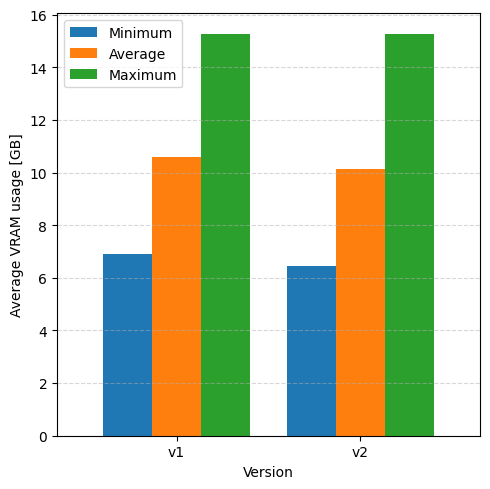

In [7]:
calculate_agg(full_df_potsdam, column="Tiempo [s]", is_time=True, title="Average training time [min]")
calculate_agg(full_df_potsdam, column="VRAM [GB]", title="Average VRAM usage [GB]")

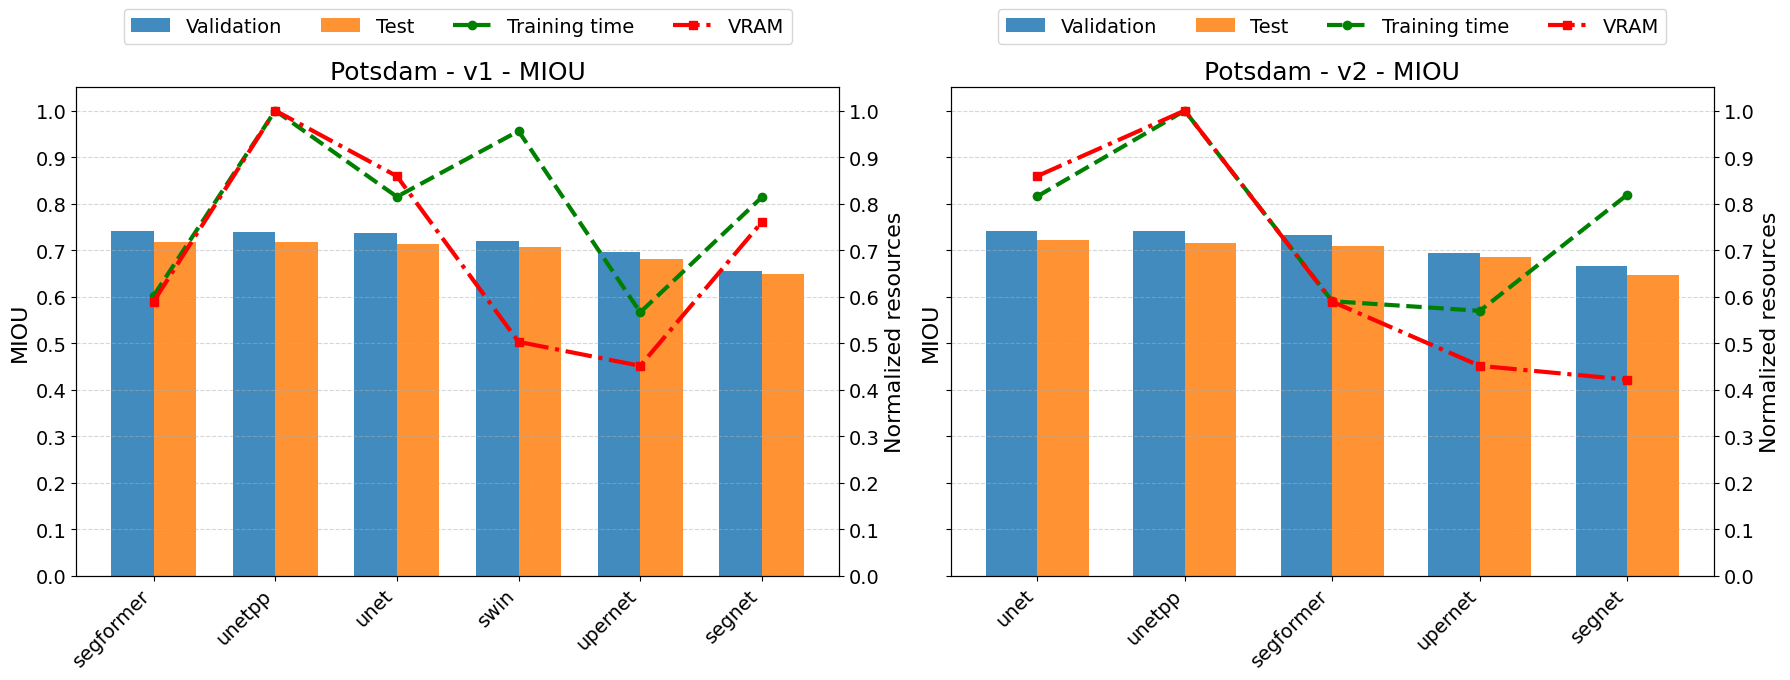

In [8]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 7),
    sharey=True
)

plot_metric(
    full_df_potsdam,
    metric="miou",
    dataset="potsdam",
    version="v1",
    ax1=axes[0],
    fontsize=16
)

plot_metric(
    full_df_potsdam,
    metric="miou",
    dataset="potsdam",
    version="v2",
    ax1=axes[1],
    fontsize=16
)

plt.tight_layout()
plt.show()

## Conclusiones

* Se puede ver que el rendimiento de los modelos es mucho más pareja para este dataset. Posiblemente por ser un data más homogéneo.
    * Segformer es el modelo con mejor rendimiento y menor uso de recursos. 
    * Lo siguen unetpp y unet pero con uno uso de recursos y tiempo de entrenamiento significativemente mayor. 
    * Se puede ver que Swin Transformer tiene un rendimiento similar pero presenta una discordancia, requiere más tiempo de entrenamiento pero utilizando menos VRAM.
    * En este caso si todos los modelos propuestos superan al baseline.

* El uso de una Loss distinta no tiene un gran efecto de degradación, pero sí genera que segformer sea el 3er mejor modelo.
* En este caso si se puede ver que Upernet+Convnext si tiene un menor tiempo de entrenamiento y de uso de VRAM con una performance comparable a los mejores modelos.

## DeadTrees

In [9]:
df_deadtrees = pd.read_csv("DeadTrees.csv")
full_df_deadtrees = df_deadtrees.merge(df, on=['dataset', 'model', 'version'], how = "left")
full_df_deadtrees["Tiempo_normalized"] = full_df_deadtrees["Tiempo [s]"]/full_df_deadtrees["Tiempo [s]"].max()
full_df_deadtrees["VRAM_normalized"] = full_df_deadtrees["VRAM [GB]"]/full_df_deadtrees["VRAM [GB]"].max()
full_df_deadtrees

,model,dataset,version,losses/val_loss,val_metrics/accuracy,val_metrics/f1,val_metrics/miou,val_metrics/precision,val_metrics/recall,losses/test_loss,test_metrics/accuracy,test_metrics/f1,test_metrics/miou,test_metrics/precision,test_metrics/recall,Tiempo [s],CPU [%],VRAM [GB],Tiempo_normalized,VRAM_normalized
0,unetpp,deadtrees,v14,0.086489,0.914539,0.902307,0.743254,0.890949,0.914539,0.056491,0.920196,0.917695,0.733119,0.915229,0.920196,4307.053223,9.526,15.383179,0.990342,1.000000
1,unetpp,deadtrees,v13,0.124914,0.908605,0.902834,0.736516,0.897263,0.908605,0.077639,0.927392,0.921718,0.742153,0.916221,0.927392,4349.057617,9.480,15.383179,1.000000,1.000000
2,unet,deadtrees,v14,0.128970,0.900286,0.903119,0.743189,0.906002,0.900286,0.082642,0.908917,0.918793,0.733763,0.929251,0.908917,3489.829590,9.960,13.180531,0.802434,0.856814
3,unet,deadtrees,v13,0.128001,0.923142,0.901085,0.737527,0.881744,0.923142,0.078726,0.935009,0.920528,0.740469,0.907147,0.935009,3503.320068,9.964,13.180531,0.805535,0.856814
4,segnet,deadtrees,v14,0.098491,0.874529,0.876057,0.683634,0.877600,0.874529,0.073351,0.893448,0.897557,0.688496,0.901770,0.893448,3275.081055,10.340,6.307520,0.753055,0.410027
5,segnet,deadtrees,v13,0.184376,0.885050,0.867959,0.673540,0.852694,0.885050,0.109265,0.904335,0.890943,0.687245,0.878570,0.904335,3286.121582,10.302,6.307520,0.755594,0.410027
6,dpt,deadtrees,v14,0.093664,0.878226,0.882072,0.683999,0.886017,0.878226,0.062302,0.895550,0.899387,0.684145,0.903314,0.895550,2792.897705,10.342,6.512189,0.642185,0.423332
7,dpt,deadtrees,v13,0.200730,0.876284,0.856994,0.659519,0.840072,0.876284,0.132857,0.870495,0.869091,0.674522,0.867700,0.870495,2793.490967,10.868,6.513654,0.642321,0.423427
8,segformer,deadtrees,v14,0.100037,0.920883,0.887546,0.730399,0.860281,0.920883,0.073077,0.927958,0.896918,0.732837,0.870822,0.927958,2158.645752,12.074,9.007707,0.496348,0.585556
9,segformer,deadtrees,v13,0.161744,0.882201,0.873834,0.691014,0.865918,0.882201,0.116333,0.898472,0.883879,0.691245,0.870510,0.898472,2188.779297,12.140,9.007707,0.503277,0.585556


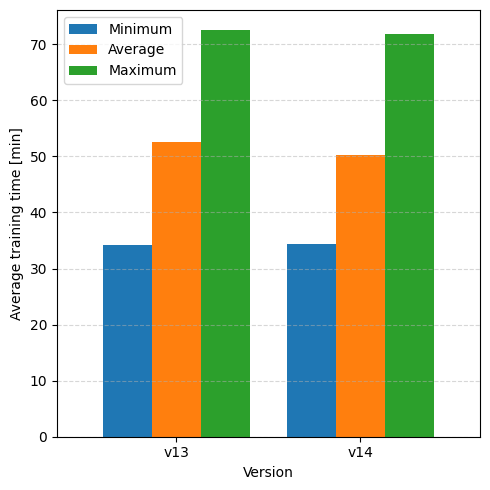

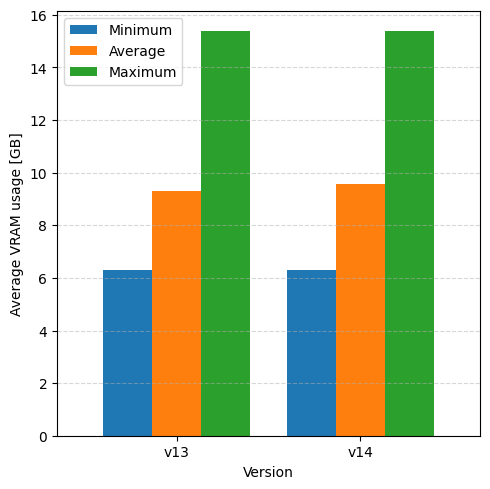

In [10]:
calculate_agg(full_df_deadtrees, column="Tiempo [s]", is_time=True, title="Average training time [min]")
calculate_agg(full_df_deadtrees, column="VRAM [GB]", title="Average VRAM usage [GB]")

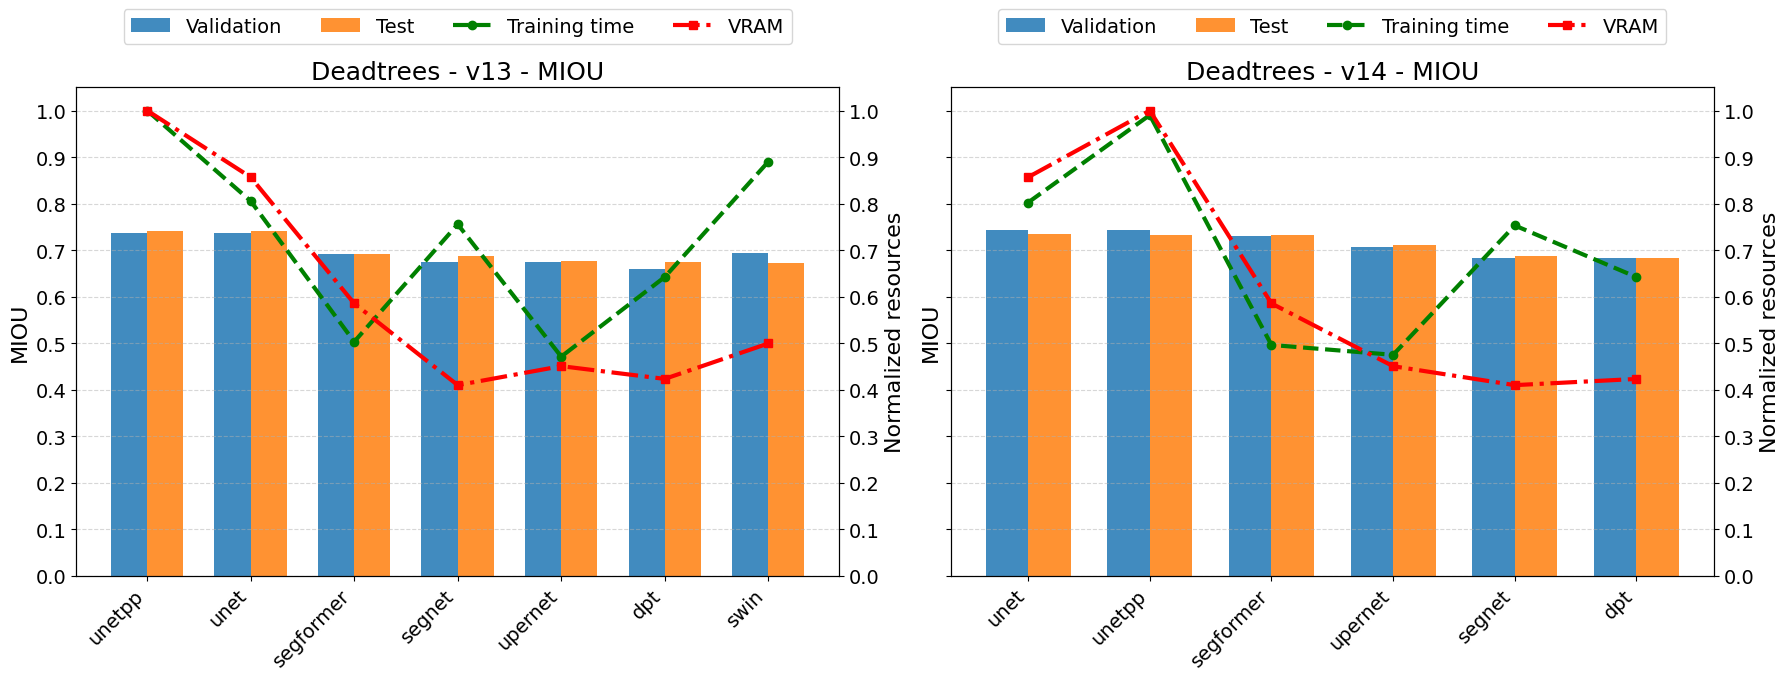

In [11]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 7),
    sharey=True
)

plot_metric(
    full_df_deadtrees,
    metric="miou",
    dataset="deadtrees",
    version="v13",
    ax1=axes[0],
    fontsize=16
)

plot_metric(
    full_df_deadtrees,
    metric="miou",
    dataset="deadtrees",
    version="v14",
    ax1=axes[1],
    fontsize=16
)

plt.tight_layout()
plt.show()

## Conclusiones

* Es posible ver que la generalización de los modelos es adecuada. 
* En general el mejor rendimiento está dado por las Unets y luego el Segformer, pero siguiendo con el mismo patrón en el cual, Segformer utiliza significativamente menos VRAM y requiere de un tiempo de entrenamiento menor.
    * Para este dataset, Upernet presenta un rendimiento muy similar a Segformer, tanto en métrica como en uso de memoria.

* Si bien es cierto no se ven grandes diferencias entre el uso de DiceLoss y CrossEntropy, Segformer sigue siendo el modelo más afectado. Se puede ver que con CrossEntropy el modelo supera los 0.7, mientras que en el caso de DiceLoss el rendimiento es cercano a 0.69.
* Además para este dataset, DPT y Swin, no obtuvieron grandes resultados, lo cual puede deberse a que el número de imágenes con árboles muertos (etiquetas positivas) es relativamente menor (hay un desbalance importante).
* En general el entrenamiento de este modelo fue bastante más inestable en términos de Loss. 


## LoveDa

In [12]:
df_loveda = pd.read_csv("LoveDA.csv")
full_df_loveda = df_loveda.merge(df, on=['dataset', 'model', 'version'], how = "left")
full_df_loveda["Tiempo_normalized"] = full_df_loveda["Tiempo [s]"]/full_df_loveda["Tiempo [s]"].max()
full_df_loveda["VRAM_normalized"] = full_df_loveda["VRAM [GB]"]/full_df_loveda["VRAM [GB]"].max()
full_df_loveda

,model,dataset,version,losses/val_loss,val_metrics/accuracy,val_metrics/f1,val_metrics/miou,val_metrics/precision,val_metrics/recall,losses/test_loss,test_metrics/accuracy,test_metrics/f1,test_metrics/miou,test_metrics/precision,test_metrics/recall,Tiempo [s],CPU [%],VRAM [GB],Tiempo_normalized,VRAM_normalized
0,unetpp,loveda,v14,0.911101,0.561434,0.567058,0.322829,0.581485,0.561434,0.919309,0.565493,0.571047,0.329683,0.586372,0.565493,26662.988281,9.004000,15.066687,0.958579,0.749251
1,unetpp,loveda,v13,0.342407,0.589346,0.589308,0.361873,0.602400,0.589346,0.343576,0.593895,0.592319,0.375351,0.602306,0.593895,26839.626953,9.254000,15.066687,0.964930,0.749251
2,unet,loveda,v14,0.945838,0.551107,0.566437,0.333810,0.600401,0.551107,0.945110,0.561129,0.578239,0.343112,0.612945,0.561129,21020.617188,9.488000,12.860765,0.755726,0.639553
3,unet,loveda,v13,0.378583,0.517096,0.516347,0.355897,0.527166,0.517096,0.381784,0.523330,0.521234,0.364700,0.526958,0.523330,21327.207031,10.166000,13.014494,0.766749,0.647198
4,segnet,loveda,v14,2.604911,0.324449,0.310921,0.162901,0.327272,0.324449,2.270506,0.335069,0.320537,0.169296,0.340564,0.335069,20582.818359,9.642000,6.331161,0.739987,0.314842
5,segnet,loveda,v13,0.430431,0.480384,0.484257,0.249635,0.532437,0.480384,0.426012,0.491298,0.500238,0.264719,0.540327,0.491298,20979.349609,9.632000,6.331161,0.754243,0.314842
6,dpt,loveda,v14,1.090349,0.572705,0.590348,0.372330,0.632627,0.572705,1.107603,0.574018,0.588962,0.380286,0.634097,0.574018,17727.855469,10.202000,6.506485,0.637346,0.323561
7,dpt,loveda,v13,0.361770,0.573032,0.588709,0.366037,0.613821,0.573032,0.358125,0.579720,0.597417,0.375419,0.625574,0.579720,17939.125000,9.990196,6.745153,0.644942,0.335430
8,segformer,loveda,v14,1.417982,0.569620,0.585144,0.364432,0.609407,0.569620,1.348748,0.575131,0.590912,0.373371,0.615660,0.575131,27620.722656,9.048000,20.108986,0.993011,1.000000
9,segformer,loveda,v13,0.337345,0.594919,0.602797,0.378502,0.622922,0.594919,0.342475,0.595671,0.603614,0.382074,0.626201,0.595671,27815.113281,8.794000,20.108986,1.000000,1.000000


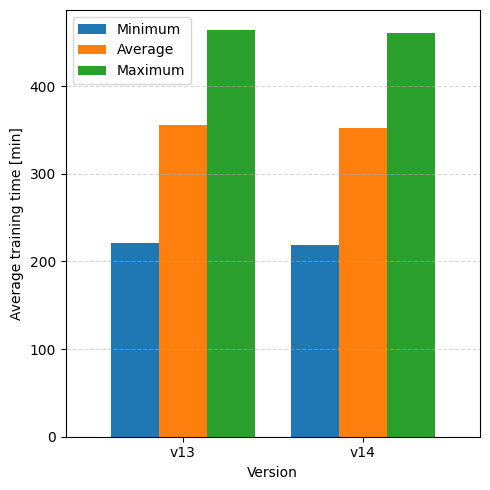

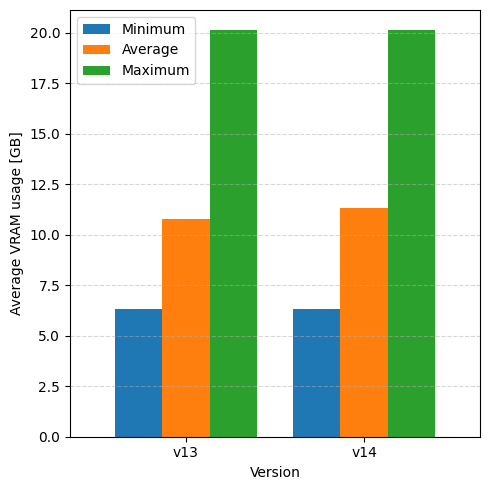

In [13]:
calculate_agg(full_df_loveda, column="Tiempo [s]", is_time=True, title="Average training time [min]")
calculate_agg(full_df_loveda, column="VRAM [GB]", title="Average VRAM usage [GB]")

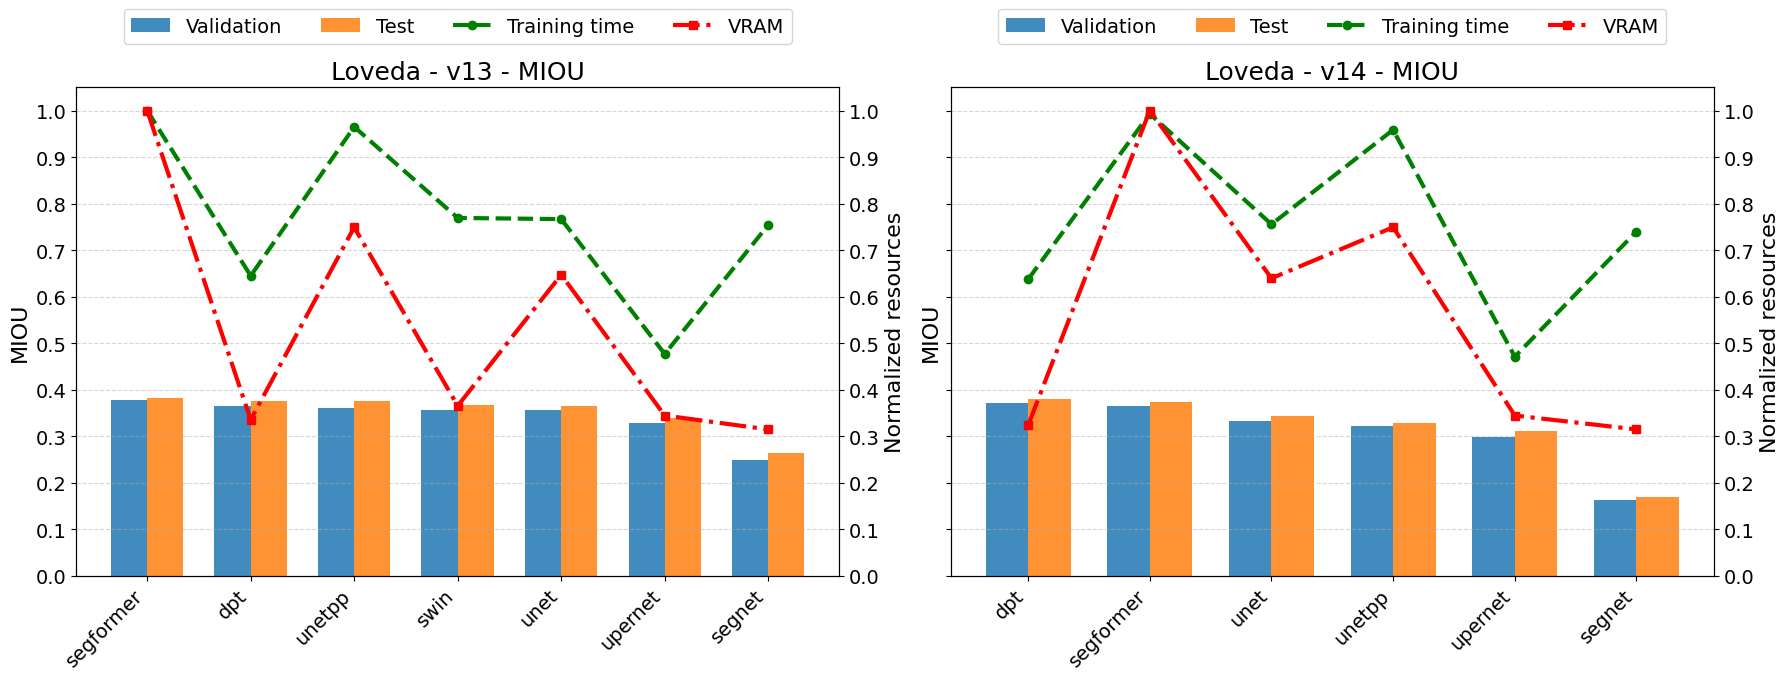

In [14]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 7),
    sharey=True
)

plot_metric(
    full_df_loveda,
    metric="miou",
    dataset="loveda",
    version="v13",
    ax1=axes[0],
    fontsize=16
)

plot_metric(
    full_df_loveda,
    metric="miou",
    dataset="loveda",
    version="v14",
    ax1=axes[1],
    fontsize=16
)

plt.tight_layout()
plt.show()